# Test – Fictief Belgisch Register
Notebook om `generate_rijksregister()` en `generate_bisregister()` te testen.

**Volgorde:**
1. Setup & imports
2. Smoke-test (kleine batch)
3. Reproduceerbaar?
4. Rijksregisternummer – structuurcontrole
5. Demografische verdelingen
6. Naamdiversiteit
7. Bisregister
8. Performancetest

## 1. Setup & imports

In [1]:
import sys
sys.path.insert(0, '../Scripts')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from datetime import date

from generate_register import generate_rijksregister, generate_bisregister

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
REFDATE = date(2026, 5, 1)
print('Imports OK')

Imports OK


## 2. Smoke-test – kleine batch

In [2]:
rr = generate_rijksregister(n=200)
print(f'Rijen: {len(rr)}  |  Kolommen: {len(rr.columns)}')
print(rr.dtypes)
rr.head(10)

Rijen: 200  |  Kolommen: 8
rijksregisternummer    object
geslacht               object
geboortedatum          object
geboorteplaats         object
geboorteland           object
nationaliteit          object
burgerlijke_staat      object
overlijdensdatum       object
dtype: object


,rijksregisternummer,geslacht,geboortedatum,geboorteplaats,geboorteland,nationaliteit,burgerlijke_staat,overlijdensdatum
0,24.04.08-998.02,F,2024-04-08,Antwerpen,België,Belgisch,gehuwd,None
1,26.04.08-998.44,F,2026-04-08,Antwerpen,België,Belgisch,ongehuwd,None
2,07.05.26-998.82,F,2007-05-26,Antwerpen,België,Marokkaans,gehuwd,None
3,71.02.13-997.21,M,1971-02-13,Seraing,België,Belgisch,gehuwd,None
4,83.02.18-998.25,F,1983-02-18,La Louvière,België,Belgisch,gescheiden,None
5,20.05.03-997.76,M,2020-05-03,Boedapest,Hongarije,EU_overig,ongehuwd,None
6,95.11.09-997.29,M,1995-11-09,Schaarbeek,België,Belgisch,ongehuwd,None
7,03.07.09-998.37,F,2003-07-09,Hasselt,België,Overig,gehuwd,None
8,06.06.13-998.70,F,2006-06-13,Gent,België,Belgisch,weduwe_weduwnaar,None
9,73.11.15-997.66,M,1973-11-15,Antwerpen,België,Belgisch,gehuwd,None


In [3]:
# Missende waarden
missing = rr.isnull().sum()
print('Missende waarden per kolom:')
print(missing[missing > 0])
print()
print('Verwacht: enkel overlijdensdatum (~0.8% van levenden)')

Missende waarden per kolom:
overlijdensdatum    200
dtype: int64

Verwacht: enkel overlijdensdatum (~0.8% van levenden)


## 3. Reproduceerbaar?

In [4]:
run_a = generate_rijksregister(n=50)
run_b = generate_rijksregister(n=50)

identical = run_a.equals(run_b)
print(f'Twee runs identiek: {identical}')
assert identical, 'FOUT: output is niet reproduceerbaar!'

print('Eerste 5 rijksregisternummers:')
print(run_a['rijksregisternummer'].head().tolist())

Twee runs identiek: True
Eerste 5 rijksregisternummers:
['24.04.08-998.02', '26.04.08-998.44', '07.05.26-998.82', '71.02.13-997.21', '83.02.18-998.25']


## 4. Rijksregisternummer – structuurcontrole

In [5]:
import re

def parse_rr(nr: str):
    """Splits RR-nummer in componenten."""
    m = re.fullmatch(r'(\d{2})\.(\d{2})\.(\d{2})-(\d{3})\.(\d{2})', nr)
    if not m:
        return None
    yy, mm, dd, seq, cc = m.groups()
    return int(yy), int(mm), int(dd), int(seq), int(cc)

def controlcijfer(yy, mm, dd, seq, born_2000_or_later: bool) -> int:
    yymmdd = f'{yy:02d}{mm:02d}{dd:02d}'
    base = ('2' if born_2000_or_later else '') + yymmdd + f'{seq:03d}'
    return 97 - (int(base) % 97)

def validate_rr(row) -> dict:
    parsed = parse_rr(row['rijksregisternummer'])
    if parsed is None:
        return {'formaat_ok': False, 'cc_ok': False, 'geslacht_ok': False, 'datum_ok': False}
    yy, mm, dd, seq, cc = parsed
    birth_year = int(row['geboortedatum'][:4])
    born_2k = birth_year >= 2000
    expected_cc = controlcijfer(yy, mm, dd, seq, born_2k)
    geslacht_ok = (row['geslacht'] == 'M' and seq % 2 == 1) or \
                  (row['geslacht'] == 'F' and seq % 2 == 0)
    datum_ok = (f'{yy:02d}' == row['geboortedatum'][2:4] and
                f'{mm:02d}' == row['geboortedatum'][5:7] and
                f'{dd:02d}' == row['geboortedatum'][8:10])
    return {
        'formaat_ok':  True,
        'cc_ok':       cc == expected_cc,
        'geslacht_ok': geslacht_ok,
        'datum_ok':    datum_ok,
    }

validatie = rr.apply(validate_rr, axis=1, result_type='expand')
print(validatie.sum())
print(f'\nAlle checks geslaagd: {validatie.all(axis=None)}')

formaat_ok     200
cc_ok          200
geslacht_ok    200
datum_ok       200
dtype: int64

Alle checks geslaagd: True


In [6]:
# Sequentienummers: hoog naar laag per geboortedatum
rr_large = generate_rijksregister(n=5000)
rr_large['seq'] = rr_large['rijksregisternummer'].str.extract(r'-(\d{3})\.').astype(int)

top_date = rr_large['geboortedatum'].value_counts().index[0]
subset = rr_large[rr_large['geboortedatum'] == top_date][['rijksregisternummer','geslacht','seq']]
print(f'Geboortedatum met meeste personen: {top_date}  ({len(subset)} personen)')
print(subset.sort_values('seq', ascending=False).to_string(index=False))
print()
for g, label in [('M','Mannen'), ('F','Vrouwen')]:
    seqs = sorted(subset[subset['geslacht']==g]['seq'].tolist(), reverse=True)
    if seqs:
        aflopend = all(seqs[i] > seqs[i+1] for i in range(len(seqs)-1))
        print(f'{label} aflopend: {seqs}  ✓' if aflopend else f'{label}: VOLGORDE FOUT {seqs}')

Geboortedatum met meeste personen: 1999-07-20  (4 personen)
rijksregisternummer geslacht  seq
    99.07.20-998.45        F  998
    99.07.20-997.46        M  997
    99.07.20-996.47        F  996
    99.07.20-994.49        F  994

Mannen aflopend: [997]  ✓
Vrouwen aflopend: [998, 996, 994]  ✓


## 5. Demografische verdelingen

In [7]:
df = generate_rijksregister(n=10_000)
df['geboortedatum'] = pd.to_datetime(df['geboortedatum'])
df['leeftijd'] = (REFDATE - df['geboortedatum'].dt.date).apply(lambda d: d.days // 365)
print(f'Generatie van {len(df):,} personen OK')
print(df[['leeftijd','geslacht','nationaliteit','burgerlijke_staat']].describe(include='all'))

Generatie van 10,000 personen OK


            leeftijd geslacht nationaliteit burgerlijke_staat
count   10000.000000    10000         10000             10000
unique           NaN        2             9                 5
top              NaN        F      Belgisch          ongehuwd
freq             NaN     5010          7460              3917
mean       38.952200      NaN           NaN               NaN
std        23.059399      NaN           NaN               NaN
min        -1.000000      NaN           NaN               NaN
25%        20.000000      NaN           NaN               NaN
50%        38.000000      NaN           NaN               NaN
75%        57.000000      NaN           NaN               NaN
max       110.000000      NaN           NaN               NaN


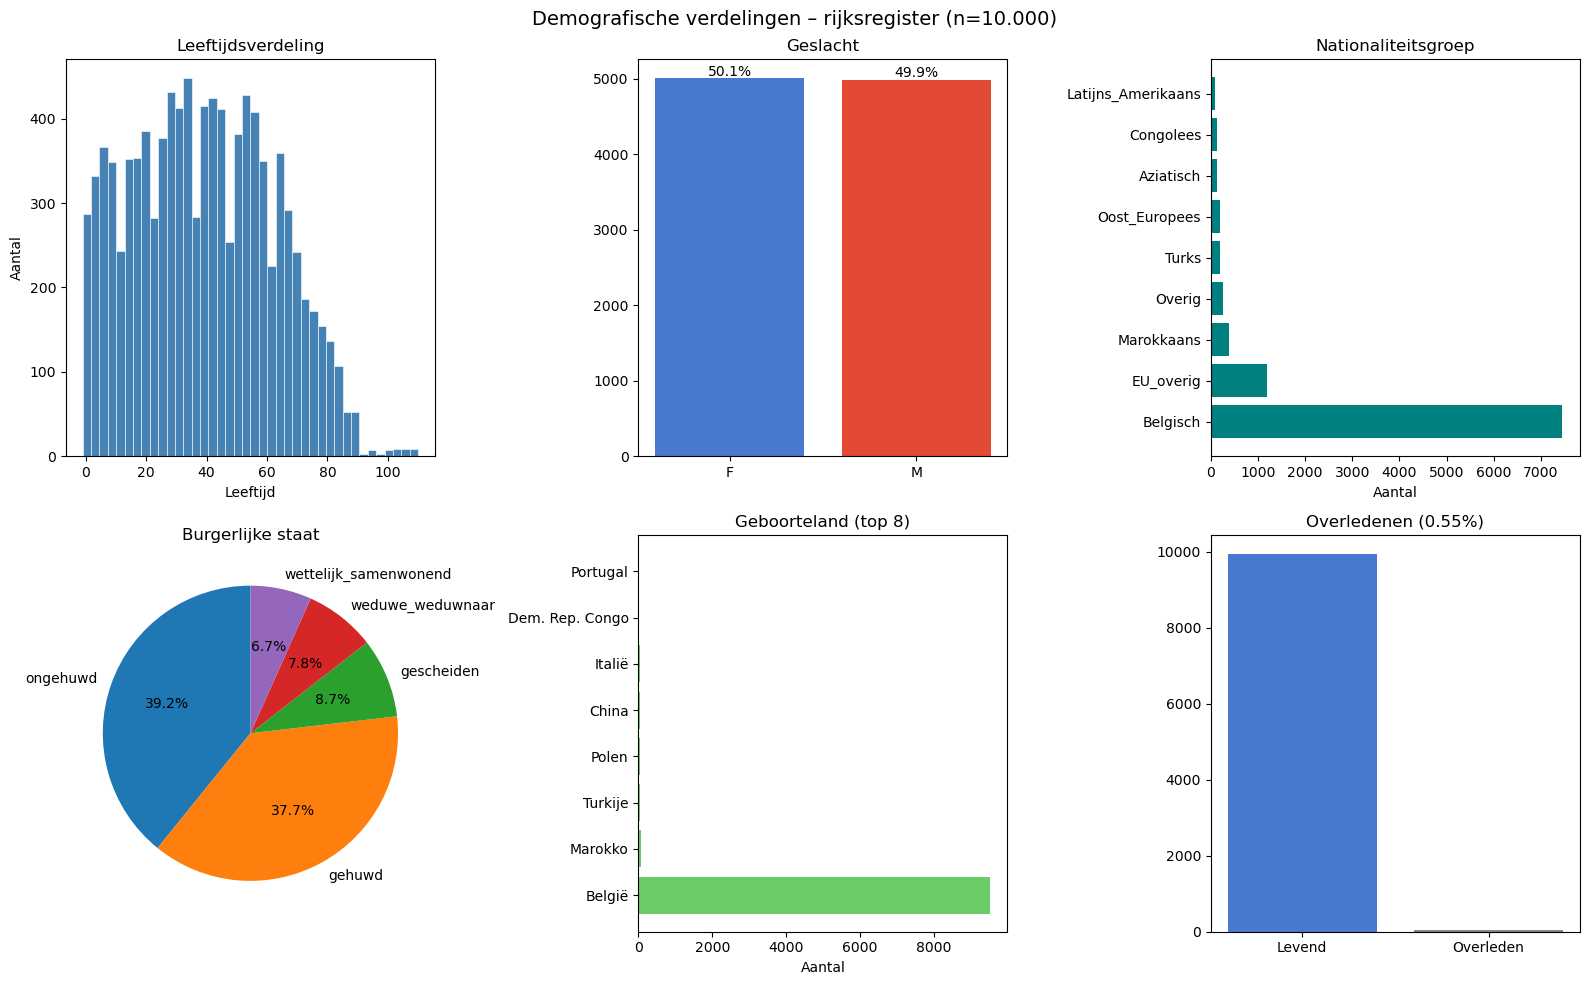

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Demografische verdelingen – rijksregister (n=10.000)', fontsize=14)

# 1. Leeftijdsverdeling
ax = axes[0, 0]
ax.hist(df['leeftijd'], bins=40, color='steelblue', edgecolor='white', linewidth=0.4)
ax.set_title('Leeftijdsverdeling')
ax.set_xlabel('Leeftijd')
ax.set_ylabel('Aantal')

# 2. Geslacht
ax = axes[0, 1]
counts = df['geslacht'].value_counts()
ax.bar(counts.index, counts.values, color=['#4878CF','#E24A33'])
ax.set_title('Geslacht')
for i, v in enumerate(counts.values):
    ax.text(i, v + 30, f'{v/len(df):.1%}', ha='center')

# 3. Nationaliteitsgroep
ax = axes[0, 2]
nat = df['nationaliteit'].value_counts()
ax.barh(nat.index, nat.values, color='teal')
ax.set_title('Nationaliteitsgroep')
ax.set_xlabel('Aantal')

# 4. Burgerlijke staat
ax = axes[1, 0]
civil = df['burgerlijke_staat'].value_counts()
ax.pie(civil.values, labels=civil.index, autopct='%1.1f%%', startangle=90)
ax.set_title('Burgerlijke staat')

# 5. Geboorteland (top 8)
ax = axes[1, 1]
gl = df['geboorteland'].value_counts().head(8)
ax.barh(gl.index, gl.values, color='#6ACC65')
ax.set_title('Geboorteland (top 8)')
ax.set_xlabel('Aantal')

# 6. Overledenen
ax = axes[1, 2]
deceased = df['overlijdensdatum'].notna()
ax.bar(['Levend', 'Overleden'], [(~deceased).sum(), deceased.sum()],
       color=['#4878CF', '#888'])
ax.set_title(f'Overledenen ({deceased.mean():.2%})')

plt.tight_layout()
plt.show()

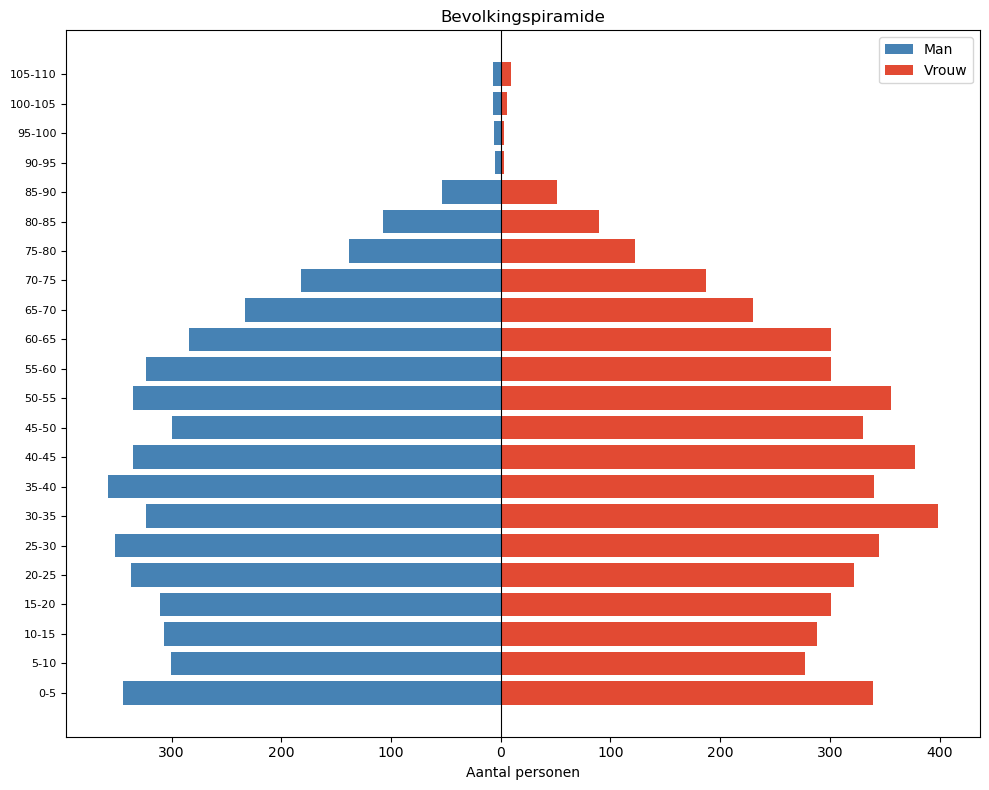

In [9]:
# Bevolkingspiramide
bins = list(range(0, 115, 5))
m_counts = df[df['geslacht']=='M']['leeftijd'].value_counts(bins=bins, sort=False)
f_counts = df[df['geslacht']=='F']['leeftijd'].value_counts(bins=bins, sort=False)

fig, ax = plt.subplots(figsize=(10, 8))
y = range(len(m_counts))
labels = [f'{int(b.left)}-{int(b.right)}' for b in m_counts.index]
ax.barh(list(y), -m_counts.values, color='steelblue', label='Man')
ax.barh(list(y), f_counts.values,  color='#E24A33', label='Vrouw')
ax.set_yticks(list(y))
ax.set_yticklabels(labels, fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: str(abs(int(x)))))
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Bevolkingspiramide')
ax.set_xlabel('Aantal personen')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Bisregister

In [10]:
bis = generate_bisregister(n=500)
print(f'BIS rijen: {len(bis)}  |  kolommen: {list(bis.columns)}')
bis.head(8)

BIS rijen: 500  |  kolommen: ['bisnummer', 'geslacht', 'geslacht_gekend', 'geboortedatum', 'geboorteplaats', 'geboorteland', 'nationaliteit', 'burgerlijke_staat']


,bisnummer,geslacht,geslacht_gekend,geboortedatum,geboorteplaats,geboorteland,nationaliteit,burgerlijke_staat
0,26.44.24-997.39,M,True,2026-04-24,Montréal,Canada,Marokkaans,wettelijk_samenwonend
1,63.28.08-998.87,X,False,1963-08-08,Parijs,Frankrijk,Marokkaans,ongehuwd
2,72.50.21-998.40,F,True,1972-10-21,Marrakech,Marokko,Aziatisch,ongehuwd
3,84.51.08-997.11,M,True,1984-11-08,Fès,Marokko,Oost_Europees,ongehuwd
4,74.42.16-998.79,F,True,1974-02-16,Abidjan,Ivoorkust,Marokkaans,gehuwd
5,98.45.21-997.67,M,True,1998-05-21,Milaan,Italië,Turks,ongehuwd
6,68.47.23-998.69,F,True,1968-07-23,Krakau,Polen,Aziatisch,ongehuwd
7,12.28.26-998.57,X,False,2012-08-26,Lima,Peru,Latijns_Amerikaans,gehuwd


In [11]:
# Valideer BIS-nummers: maand moet 21-32 (offset 20) of 41-52 (offset 40) zijn
import re

def parse_bis(row):
    m = re.fullmatch(r'(\d{2})\.(\d{2})\.(\d{2})-(\d{3})\.(\d{2})', row['bisnummer'])
    if not m:
        return {'formaat_ok': False, 'maand_offset_ok': False, 'geslacht_ok': False}
    yy, mm, dd, seq, cc = (int(x) for x in m.groups())
    offset_ok = (20 < mm <= 32) or (40 < mm <= 52)  # maand+20 of maand+40
    if row['geslacht'] == 'X':
        geslacht_ok = (20 < mm <= 32)  # offset 20 = onbekend geslacht
    else:
        geslacht_ok = (40 < mm <= 52)  # offset 40 = gekend geslacht
        if row['geslacht'] == 'M':
            geslacht_ok = geslacht_ok and (seq % 2 == 1)
        else:
            geslacht_ok = geslacht_ok and (seq % 2 == 0)
    return {'formaat_ok': True, 'maand_offset_ok': offset_ok, 'geslacht_ok': geslacht_ok}

bis_val = bis.apply(parse_bis, axis=1, result_type='expand')
print(bis_val.sum())
print(f'Alle checks geslaagd: {bis_val.all(axis=None)}')

formaat_ok         500
maand_offset_ok    500
geslacht_ok        500
dtype: int64
Alle checks geslaagd: True


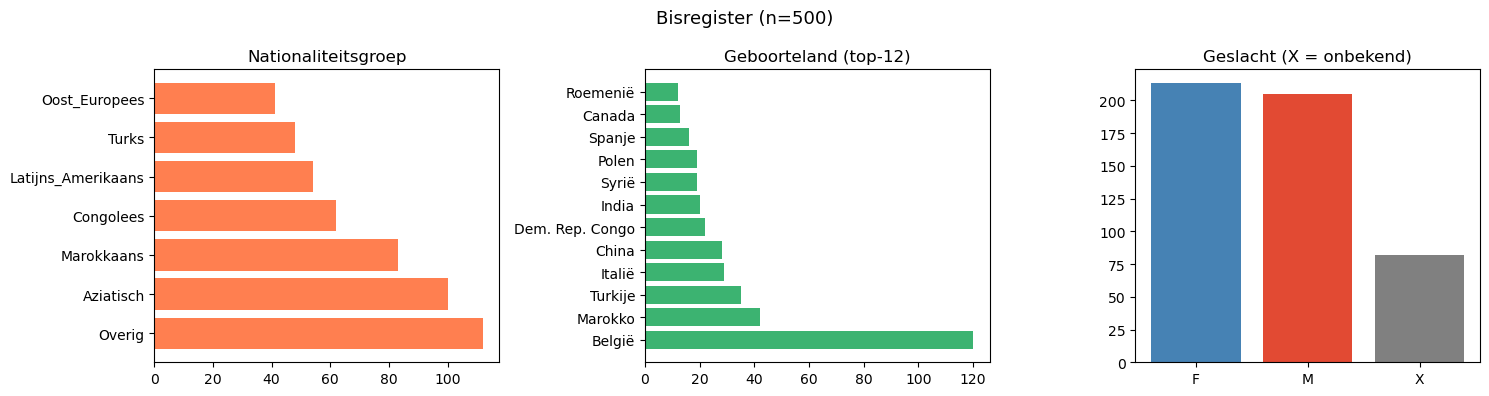

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Bisregister (n=500)', fontsize=13)

nat = bis['nationaliteit'].value_counts()
axes[0].barh(nat.index, nat.values, color='coral')
axes[0].set_title('Nationaliteitsgroep')

gl = bis['geboorteland'].value_counts().head(12)
axes[1].barh(gl.index, gl.values, color='mediumseagreen')
axes[1].set_title('Geboorteland (top-12)')

gsl = bis['geslacht'].value_counts()
axes[2].bar(gsl.index, gsl.values, color=['steelblue','#E24A33','grey'])
axes[2].set_title('Geslacht (X = onbekend)')

plt.tight_layout()
plt.show()

In [13]:
# Overlap RR ↔ BIS: geen enkel nummer mag identiek zijn
rr_nrs  = set(generate_rijksregister(n=1000)['rijksregisternummer'])
bis_nrs = set(generate_bisregister(n=1000)['bisnummer'])
overlap = rr_nrs & bis_nrs
print(f'Overlap rijksregister ↔ bisregister: {len(overlap)} nummers')
assert len(overlap) == 0, f'FOUT: {len(overlap)} dubbele nummers gevonden!'
print('✓ Geen overlap')

Overlap rijksregister ↔ bisregister: 0 nummers
✓ Geen overlap


## 8. Performancetest

In [14]:
import time

for n in [1_000, 10_000, 50_000, 100_000]:
    t0 = time.perf_counter()
    _ = generate_rijksregister(n=n)
    elapsed = time.perf_counter() - t0
    print(f'{n:>8,} personen  →  {elapsed:.2f}s  ({n/elapsed:,.0f} personen/s)')

   1,000 personen  →  0.02s  (59,569 personen/s)
  10,000 personen  →  0.17s  (58,560 personen/s)


  50,000 personen  →  0.73s  (68,458 personen/s)


 100,000 personen  →  1.27s  (78,766 personen/s)


In [15]:
# Extrapolatie naar 1.000.000
t0 = time.perf_counter()
sample = generate_rijksregister(n=10_000)
rate = 10_000 / (time.perf_counter() - t0)
print(f'Verwachte tijd voor 1.000.000 personen: {1_000_000 / rate:.0f}s  (~{1_000_000 / rate / 60:.1f} min)')

Verwachte tijd voor 1.000.000 personen: 14s  (~0.2 min)
